In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [18]:
# ========================================
# 1. DOWNLOAD DATA DARI YAHOO FINANCE
# ========================================
print("Mengunduh data IHSG dari Yahoo Finance...")
# ^JKSE adalah ticker untuk IHSG di Yahoo Finance
ticker = "^JKSE"
start_date = "2015-01-01"
end_date = "2024-12-31"

df = yf.download(ticker, start=start_date, end=end_date)
print(f"Data berhasil diunduh: {len(df)} baris")
print(df.head())

# Gunakan kolom Close untuk prediksi
data = df[['Close']].copy()
data.columns = ['IHSG']


[*********************100%***********************]  1 of 1 completed

Mengunduh data IHSG dari Yahoo Finance...
Data berhasil diunduh: 2425 baris
Price             Close         High          Low         Open    Volume
Ticker            ^JKSE        ^JKSE        ^JKSE        ^JKSE     ^JKSE
Date                                                                    
2015-01-02  5242.564941  5247.733685  5230.546366  5233.592146  38133000
2015-01-05  5219.791992  5233.456500  5206.082565  5229.480580  44846100
2015-01-06  5168.858398  5194.600558  5168.858398  5186.001773  51516500
2015-01-07  5206.915039  5207.172842  5174.594034  5175.352306  72088500
2015-01-08  5211.625000  5229.975359  5208.790150  5218.196521  69163000


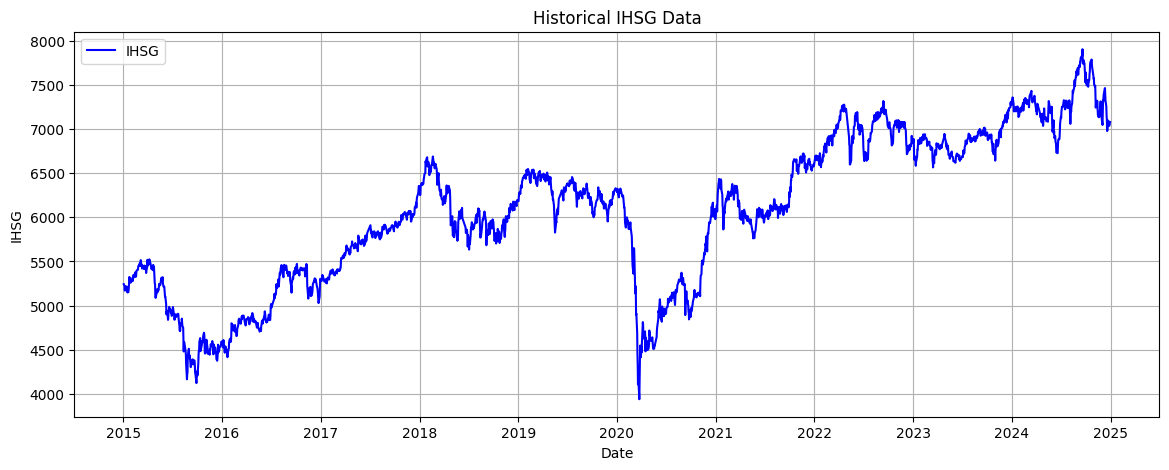

In [19]:
# ========================================
# 2. EXPLORATORY DATA ANALYSIS
# ========================================
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['IHSG'], label='IHSG', color='blue')
plt.title('Historical IHSG Data')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# ========================================
# 3. SPLIT DATA (80% TRAIN, 20% TEST)
# ========================================
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print(f"Training data: {len(train_data)} baris")
print(f"Testing data: {len(test_data)} baris")

Training data: 1940 baris
Testing data: 485 baris


In [21]:
# ========================================
# 4. MODEL ARIMAX
# ========================================
print("\n=== Tahap 1: Modeling ARIMAX ===")

# Tambahkan variabel eksogen (contoh: moving average, lag features)
train_arimax = train_data.copy()
train_arimax['MA7'] = train_arimax['IHSG'].rolling(window=7).mean()
train_arimax['MA30'] = train_arimax['IHSG'].rolling(window=30).mean()
train_arimax = train_arimax.dropna()

test_arimax = test_data.copy()
test_arimax['MA7'] = test_arimax['IHSG'].rolling(window=7).mean()
test_arimax['MA30'] = test_arimax['IHSG'].rolling(window=30).mean()
test_arimax = test_arimax.dropna()

# Variabel eksogen
exog_train = train_arimax[['MA7', 'MA30']]
exog_test = test_arimax[['MA7', 'MA30']]

# Fit ARIMAX model (order dapat disesuaikan)
# Format: SARIMAX(endog, exog, order=(p,d,q))
print("Fitting ARIMAX model...")
arimax_model = SARIMAX(train_arimax['IHSG'],
                        exog=exog_train,
                        order=(2, 1, 2),  # (p, d, q) - bisa di-tuning
                        enforce_stationarity=False,
                        enforce_invertibility=False)

arimax_fit = arimax_model.fit(disp=False)
print("ARIMAX model berhasil di-fit")

# Prediksi dengan ARIMAX
arimax_pred_train = arimax_fit.predict(start=0, end=len(train_arimax)-1, exog=exog_train)
arimax_pred_test = arimax_fit.predict(start=len(train_arimax),
                                       end=len(train_arimax)+len(test_arimax)-1,
                                       exog=exog_test)

# Hitung residual (error) dari ARIMAX
residual_train = train_arimax['IHSG'] - arimax_pred_train
residual_test = test_arimax['IHSG'] - arimax_pred_test

print(f"ARIMAX RMSE on test: {np.sqrt(mean_squared_error(test_arimax['IHSG'], arimax_pred_test)):.2f}")



=== Tahap 1: Modeling ARIMAX ===
Fitting ARIMAX model...
ARIMAX model berhasil di-fit
ARIMAX RMSE on test: 65.42


In [22]:
# ========================================
# 5. MODEL LSTM UNTUK RESIDUAL
# ========================================
print("\n=== Tahap 2: Modeling LSTM untuk Residual ===")

# Fungsi untuk membuat dataset supervised learning
def create_dataset(data, look_back=30):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# IMPORTANT: Kita harus membuat dataset LSTM dari GABUNGAN train+test residual
# kemudian split lagi, agar tidak ada data leakage
# Normalisasi residual
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler hanya pada train residual
scaler.fit(residual_train.values.reshape(-1, 1))

# Transform train dan test residual
residual_train_scaled = scaler.transform(residual_train.values.reshape(-1, 1))
residual_test_scaled = scaler.transform(residual_test.values.reshape(-1, 1))

# Buat dataset untuk LSTM dari masing-masing train dan test
look_back = 30
X_train_lstm, y_train_lstm = create_dataset(residual_train_scaled, look_back)
X_test_lstm, y_test_lstm = create_dataset(residual_test_scaled, look_back)

# Reshape untuk LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

print(f"Residual train length: {len(residual_train)}")
print(f"Residual test length: {len(residual_test)}")
print(f"LSTM Training shape: {X_train_lstm.shape}")
print(f"LSTM Testing shape: {X_test_lstm.shape}")
print(f"Y train shape: {y_train_lstm.shape}")
print(f"Y test shape: {y_test_lstm.shape}")

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train LSTM
print("Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi residual dengan LSTM
lstm_pred_train_scaled = lstm_model.predict(X_train_lstm)
lstm_pred_test_scaled = lstm_model.predict(X_test_lstm)

# Inverse transform
lstm_pred_train = scaler.inverse_transform(lstm_pred_train_scaled)
lstm_pred_test = scaler.inverse_transform(lstm_pred_test_scaled)



=== Tahap 2: Modeling LSTM untuk Residual ===
Residual train length: 1911
Residual test length: 912
LSTM Training shape: (1881, 30, 1)
LSTM Testing shape: (882, 30, 1)
Y train shape: (1881, 1)
Y test shape: (882, 1)
Training LSTM model...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0258 - val_loss: 0.0061
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - val_loss: 0.0061
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0057 - val_loss: 0.0062
Epo

In [23]:
# ========================================
# 6. HYBRID MODEL (ARIMAX + LSTM)
# ========================================
print("\n=== Tahap 3: Kombinasi ARIMAX + LSTM ===")

# Debug: Cek panjang data
print(f"Length arimax_pred_train: {len(arimax_pred_train)}")
print(f"Length lstm_pred_train: {len(lstm_pred_train)}")
print(f"Length arimax_pred_test: {len(arimax_pred_test)}")
print(f"Length lstm_pred_test: {len(lstm_pred_test)}")

# Potong semua data agar sesuai dengan output LSTM (yang paling pendek)
# Untuk train
min_train_len = min(len(lstm_pred_train), len(arimax_pred_train) - look_back)
arimax_train_aligned = arimax_pred_train.values[look_back:look_back+min_train_len]
lstm_train_aligned = lstm_pred_train[:min_train_len].flatten()
actual_train_aligned = train_arimax['IHSG'].values[look_back:look_back+min_train_len]

# Untuk test
min_test_len = min(len(lstm_pred_test), len(arimax_pred_test) - look_back)
arimax_test_aligned = arimax_pred_test.values[look_back:look_back+min_test_len]
lstm_test_aligned = lstm_pred_test[:min_test_len].flatten()
actual_test_aligned = test_arimax['IHSG'].values[look_back:look_back+min_test_len]

# Gabungkan ARIMAX + LSTM
hybrid_train = arimax_train_aligned + lstm_train_aligned
hybrid_test = arimax_test_aligned + lstm_test_aligned

# Assign ke variabel yang lebih sederhana
actual_train = actual_train_aligned
actual_test = actual_test_aligned

print(f"\nAfter alignment:")
print(f"Length hybrid_train: {len(hybrid_train)}")
print(f"Length hybrid_test: {len(hybrid_test)}")
print(f"Length actual_train: {len(actual_train)}")
print(f"Length actual_test: {len(actual_test)}")



=== Tahap 3: Kombinasi ARIMAX + LSTM ===
Length arimax_pred_train: 1911
Length lstm_pred_train: 1881
Length arimax_pred_test: 456
Length lstm_pred_test: 882

After alignment:
Length hybrid_train: 1881
Length hybrid_test: 426
Length actual_train: 1881
Length actual_test: 426


In [24]:
# ========================================
# 7. EVALUASI MODEL
# ========================================
print("\n=== Evaluasi Model ===")

def evaluate_model(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return rmse, mae, r2, mape

# Evaluasi ARIMAX saja (dengan aligned data)
arimax_test_for_eval = arimax_pred_test.values[look_back:look_back+min_test_len]
actual_test_for_arimax = test_arimax['IHSG'].values[look_back:look_back+min_test_len]
evaluate_model(actual_test_for_arimax, arimax_test_for_eval, "ARIMAX Only (Test)")

# Evaluasi Hybrid
evaluate_model(actual_test, hybrid_test, "Hybrid ARIMAX-LSTM (Test)")



=== Evaluasi Model ===

ARIMAX Only (Test):
  RMSE: 67.18
  MAE: 51.00
  R2 Score: 0.9490
  MAPE: 0.71%


ValueError: Input contains NaN.

In [ ]:
# ========================================
# 8. VISUALISASI HASIL
# ========================================
plt.figure(figsize=(16, 8))

# Plot training data
plt.subplot(2, 1, 1)
train_dates = train_arimax.index[look_back:look_back+len(hybrid_train)]
plt.plot(train_dates, actual_train, label='Actual Train', color='blue', linewidth=1.5)
plt.plot(train_dates, hybrid_train, label='Hybrid Prediction', color='red', linewidth=1.5, alpha=0.7)
plt.title('IHSG - Training Set (Hybrid ARIMAX-LSTM)')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)

# Plot testing data
plt.subplot(2, 1, 2)
test_dates = test_arimax.index[look_back:look_back+len(hybrid_test)]
plt.plot(test_dates, actual_test, label='Actual Test', color='blue', linewidth=1.5)
plt.plot(test_dates, arimax_test_aligned, label='ARIMAX Only',
         color='green', linewidth=1.5, alpha=0.5, linestyle='--')
plt.plot(test_dates, hybrid_test, label='Hybrid ARIMAX-LSTM', color='red', linewidth=1.5)
plt.title('IHSG - Testing Set Prediction Comparison')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot training loss LSTM
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ========================================
# 9. PREDIKSI MASA DEPAN (CONTOH)
# ========================================
print("\n=== Prediksi 30 Hari ke Depan ===")

# Untuk prediksi masa depan, kita perlu menggunakan data terakhir
last_data = data.tail(60).copy()
last_data['MA7'] = last_data['IHSG'].rolling(window=7).mean()
last_data['MA30'] = last_data['IHSG'].rolling(window=30).mean()
last_data = last_data.dropna()

# Prediksi ARIMAX untuk 30 hari ke depan
future_exog = last_data[['MA7', 'MA30']].tail(30)  # Gunakan MA terakhir sebagai proxy
future_arimax = arimax_fit.forecast(steps=30, exog=future_exog)

print(f"Prediksi IHSG 30 hari ke depan (ARIMAX):")
print(future_arimax)

# Plot prediksi masa depan
plt.figure(figsize=(14, 5))
plt.plot(data.index[-100:], data['IHSG'][-100:], label='Historical', color='blue')
future_dates = pd.date_range(start=data.index[-1], periods=31, freq='D')[1:]
plt.plot(future_dates, future_arimax, label='Future Forecast (30 days)',
         color='red', marker='o', linestyle='--')
plt.title('IHSG Future Forecast')
plt.xlabel('Date')
plt.ylabel('IHSG')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Selesai ===")
print("Model hybrid ARIMAX-LSTM telah berhasil diimplementasikan!")